# 🔍 Aadhaar Enrolment & Updates - Societal Trends Analysis

## Problem Statement
Identify meaningful patterns, trends, anomalies, or predictive indicators in Aadhaar enrollment data and translate them into actionable insights.

## Dataset Overview
| Dataset | Description | Records |
|---------|-------------|---------|
| **Biometric** | Biometric updates by age groups (5-17, 17+) | ~1.86M rows |
| **Demographic** | Demographic updates by age groups | ~2.07M rows |
| **Enrolment** | New enrollments by age (0-5, 5-17, 18+) | ~1M rows |

## Analysis Roadmap
1. **Data Loading & Preprocessing** - Load, merge, clean data
2. **Exploratory Data Analysis (EDA)** - Distributions, statistics
3. **Temporal Trends** - Time-series patterns
4. **Geographic Analysis** - State/district level insights
5. **Age Group Analysis** - Demographic patterns
6. **Anomaly Detection** - Identify outliers
7. **Predictive Modeling** - Forecast future trends
8. **Insights & Recommendations**

## 1. Data Loading & Preprocessing

In [30]:
# Install required packages (run this cell first!)
%pip install seaborn matplotlib pandas numpy -q

Note: you may need to restart the kernel to use updated packages.


In [31]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [32]:
# Function to load and concatenate multiple CSV files
def load_dataset(folder_path, dataset_name):
    """Load all CSV files from a folder and concatenate them"""
    files = glob(f"{folder_path}/*.csv")
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        dfs.append(df)
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"{dataset_name}: Loaded {len(files)} files with {len(combined_df):,} total rows")
    return combined_df


# Load all three datasets
df_biometric = load_dataset(f"dataset/api_data_aadhar_biometric", "Biometric")
df_demographic = load_dataset(f"dataset/api_data_aadhar_demographic", "Demographic")
df_enrolment = load_dataset(f"dataset/api_data_aadhar_enrolment", "Enrolment")

Biometric: Loaded 4 files with 1,861,108 total rows
Demographic: Loaded 5 files with 2,071,700 total rows
Enrolment: Loaded 3 files with 1,006,029 total rows


In [33]:
# Data preprocessing
def preprocess_data(df, name):
    """Clean and preprocess the dataframe"""
    # Convert date column
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
    
    # Extract time features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['month_name'] = df['date'].dt.month_name()
    df['day_of_week'] = df['date'].dt.day_name()
    df['week_of_year'] = df['date'].dt.isocalendar().week
    
    # Handle missing values
    print(f"\n{name} Dataset Info:")
    print(f"   Shape: {df.shape}")
    print(f"   Missing values:\n{df.isnull().sum()}")
    print(f"   Date range: {df['date'].min()} to {df['date'].max()}")
    
    return df

# Preprocess all datasets
df_biometric = preprocess_data(df_biometric, "Biometric")
df_demographic = preprocess_data(df_demographic, "Demographic")
df_enrolment = preprocess_data(df_enrolment, "Enrolment")


Biometric Dataset Info:
   Shape: (1861108, 11)
   Missing values:
date            0
state           0
district        0
pincode         0
bio_age_5_17    0
bio_age_17_     0
year            0
month           0
month_name      0
day_of_week     0
week_of_year    0
dtype: int64
   Date range: 2025-03-01 00:00:00 to 2025-12-29 00:00:00

Demographic Dataset Info:
   Shape: (2071700, 11)
   Missing values:
date             0
state            0
district         0
pincode          0
demo_age_5_17    0
demo_age_17_     0
year             0
month            0
month_name       0
day_of_week      0
week_of_year     0
dtype: int64
   Date range: 2025-03-01 00:00:00 to 2025-12-29 00:00:00

Enrolment Dataset Info:
   Shape: (1006029, 12)
   Missing values:
date              0
state             0
district          0
pincode           0
age_0_5           0
age_5_17          0
age_18_greater    0
year              0
month             0
month_name        0
day_of_week       0
week_of_year      0
dtype

In [34]:
# Preview the datasets
print("BIOMETRIC Dataset (sample):")
display(df_biometric.head())

print("\nDEMOGRAPHIC Dataset (sample):")
display(df_demographic.head())

print("\nENROLMENT Dataset (sample):")
display(df_enrolment.head())

BIOMETRIC Dataset (sample):


,date,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,month_name,day_of_week,week_of_year
0,2025-09-19,Goa,North Goa,403502,0,4,2025,9,September,Friday,38
1,2025-09-19,Goa,North Goa,403508,1,4,2025,9,September,Friday,38
2,2025-09-19,Goa,North Goa,403513,2,0,2025,9,September,Friday,38
3,2025-09-19,Goa,North Goa,403527,2,2,2025,9,September,Friday,38
4,2025-09-19,Goa,South Goa,403601,7,3,2025,9,September,Friday,38



DEMOGRAPHIC Dataset (sample):


,date,state,district,pincode,demo_age_5_17,demo_age_17_,year,month,month_name,day_of_week,week_of_year
0,2025-11-18,Karnataka,Hasan,573118,0,2,2025,11,November,Tuesday,47
1,2025-11-18,Karnataka,Hasan,573124,1,3,2025,11,November,Tuesday,47
2,2025-11-18,Karnataka,Hasan,573150,0,2,2025,11,November,Tuesday,47
3,2025-11-18,Karnataka,Hassan,573113,0,1,2025,11,November,Tuesday,47
4,2025-11-18,Karnataka,Hassan,573120,1,4,2025,11,November,Tuesday,47



ENROLMENT Dataset (sample):


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,year,month,month_name,day_of_week,week_of_year
0,2025-12-31,Karnataka,Bidar,585330,2,3,0,2025,12,December,Wednesday,1
1,2025-12-31,Karnataka,Bidar,585402,6,0,0,2025,12,December,Wednesday,1
2,2025-12-31,Karnataka,Bidar,585413,1,0,0,2025,12,December,Wednesday,1
3,2025-12-31,Karnataka,Bidar,585418,1,2,0,2025,12,December,Wednesday,1
4,2025-12-31,Karnataka,Bidar,585421,4,3,0,2025,12,December,Wednesday,1


## 2. Exploratory Data Analysis (EDA)

In [35]:
# Statistical summary of numerical columns
print("📈 ENROLMENT - Statistical Summary (Age Groups):")
display(df_enrolment[['age_0_5', 'age_5_17', 'age_18_greater']].describe())

print("\n📈 BIOMETRIC - Statistical Summary:")
display(df_biometric[['bio_age_5_17', 'bio_age_17_']].describe())

print("\n📈 DEMOGRAPHIC - Statistical Summary:")
display(df_demographic[['demo_age_5_17', 'demo_age_17_']].describe())

📈 ENROLMENT - Statistical Summary (Age Groups):


,age_0_5,age_5_17,age_18_greater
count,1.006029e+06,1.006029e+06,1.006029e+06
mean,3.525709e+00,1.710074e+00,1.673441e-01
std,1.753851e+01,1.436963e+01,3.220525e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,0.000000e+00
75%,3.000000e+00,1.000000e+00,0.000000e+00
max,2.688000e+03,1.812000e+03,8.550000e+02



📈 BIOMETRIC - Statistical Summary:


,bio_age_5_17,bio_age_17_
count,1.861108e+06,1.861108e+06
mean,1.839058e+01,1.909413e+01
std,8.370421e+01,8.806502e+01
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00
50%,3.000000e+00,4.000000e+00
75%,1.100000e+01,1.000000e+01
max,8.002000e+03,7.625000e+03



📈 DEMOGRAPHIC - Statistical Summary:


,demo_age_5_17,demo_age_17_
count,2.071700e+06,2.071700e+06
mean,2.347552e+00,2.144701e+01
std,1.490355e+01,1.252498e+02
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,2.000000e+00
50%,1.000000e+00,6.000000e+00
75%,2.000000e+00,1.500000e+01
max,2.690000e+03,1.616600e+04


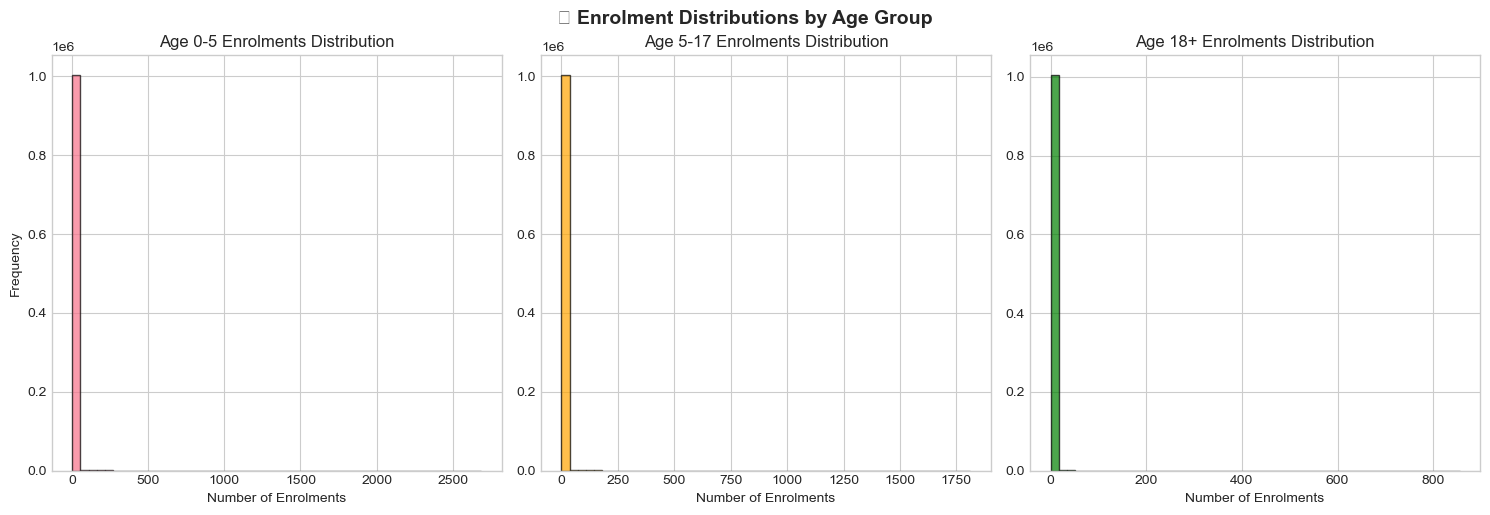

In [36]:
# Distribution of enrolments by age groups
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Enrolment age distributions
df_enrolment['age_0_5'].hist(ax=axes[0], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Age 0-5 Enrolments Distribution', fontsize=12)
axes[0].set_xlabel('Number of Enrolments')
axes[0].set_ylabel('Frequency')

df_enrolment['age_5_17'].hist(ax=axes[1], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Age 5-17 Enrolments Distribution', fontsize=12)
axes[1].set_xlabel('Number of Enrolments')

df_enrolment['age_18_greater'].hist(ax=axes[2], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('Age 18+ Enrolments Distribution', fontsize=12)
axes[2].set_xlabel('Number of Enrolments')

plt.tight_layout()
plt.suptitle('📊 Enrolment Distributions by Age Group', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 3. Geographic Analysis - State-wise Trends

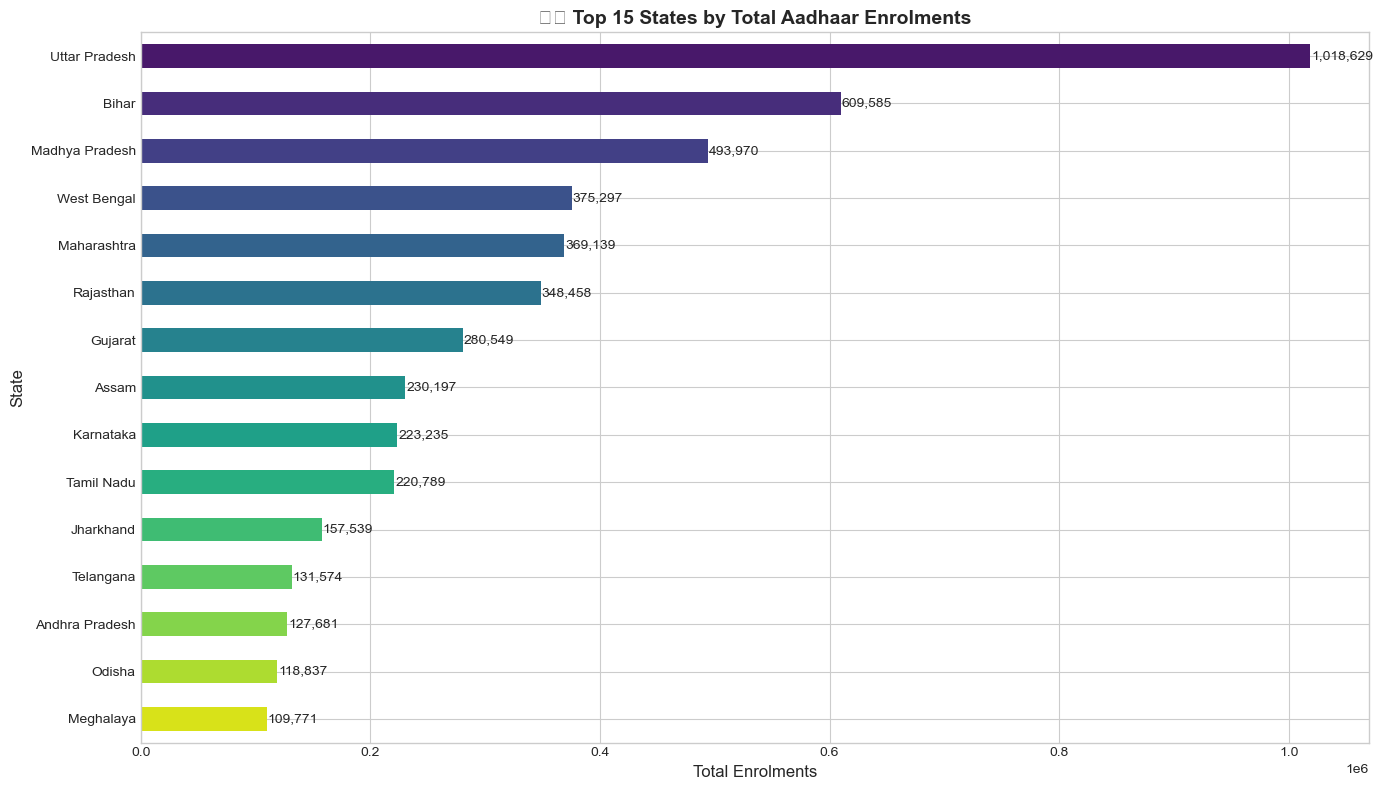


📊 Total States/UTs in data: 55


In [37]:
# State-wise total enrolments
df_enrolment['total_enrolment'] = df_enrolment['age_0_5'] + df_enrolment['age_5_17'] + df_enrolment['age_18_greater']

state_enrolment = df_enrolment.groupby('state')['total_enrolment'].sum().sort_values(ascending=False)

# Top 15 states by enrolment
fig, ax = plt.subplots(figsize=(14, 8))
state_enrolment.head(15).plot(kind='barh', ax=ax, color=sns.color_palette("viridis", 15))
ax.set_xlabel('Total Enrolments', fontsize=12)
ax.set_ylabel('State', fontsize=12)
ax.set_title('🗺️ Top 15 States by Total Aadhaar Enrolments', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(state_enrolment.head(15).values):
    ax.text(v + 1000, i, f'{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 Total States/UTs in data: {df_enrolment['state'].nunique()}")

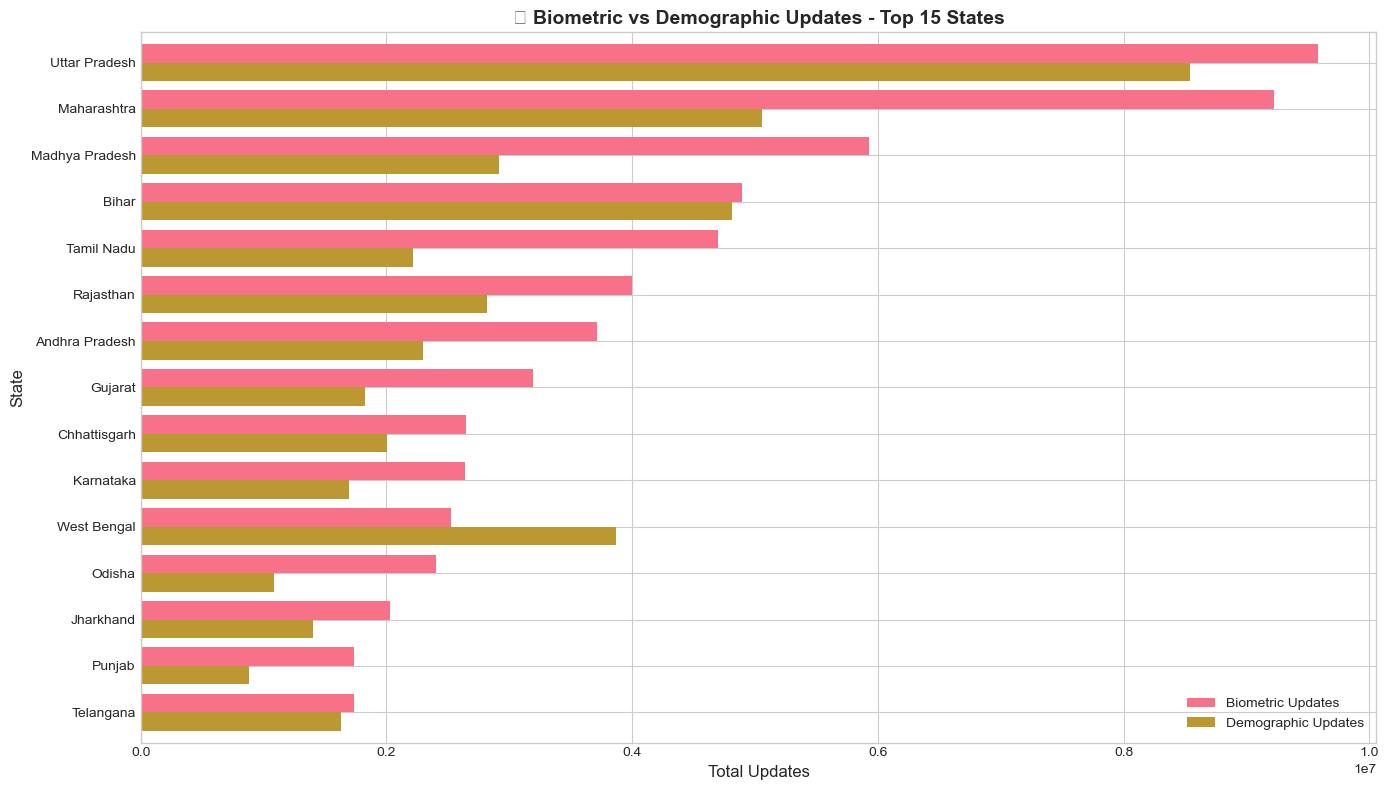

In [38]:
# Compare biometric vs demographic updates by state
df_biometric['total_bio'] = df_biometric['bio_age_5_17'] + df_biometric['bio_age_17_']
df_demographic['total_demo'] = df_demographic['demo_age_5_17'] + df_demographic['demo_age_17_']

state_bio = df_biometric.groupby('state')['total_bio'].sum()
state_demo = df_demographic.groupby('state')['total_demo'].sum()

# Merge and compare
state_comparison = pd.DataFrame({
    'Biometric Updates': state_bio,
    'Demographic Updates': state_demo
}).fillna(0).sort_values('Biometric Updates', ascending=False).head(15)

# Stacked bar chart
state_comparison.plot(kind='barh', figsize=(14, 8), width=0.8)
plt.xlabel('Total Updates', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.title('🔄 Biometric vs Demographic Updates - Top 15 States', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Temporal Analysis - Time Series Trends


Daily Enrolment Trends (sample): 



,date,age_0_5,age_5_17,age_18_greater,total_enrolment
0,2025-03-02,11,61,37,109
1,2025-03-09,1037,1777,590,3404
2,2025-03-15,710,1561,831,3102
3,2025-03-20,2291,2533,1394,6218
4,2025-03-23,138,259,179,576


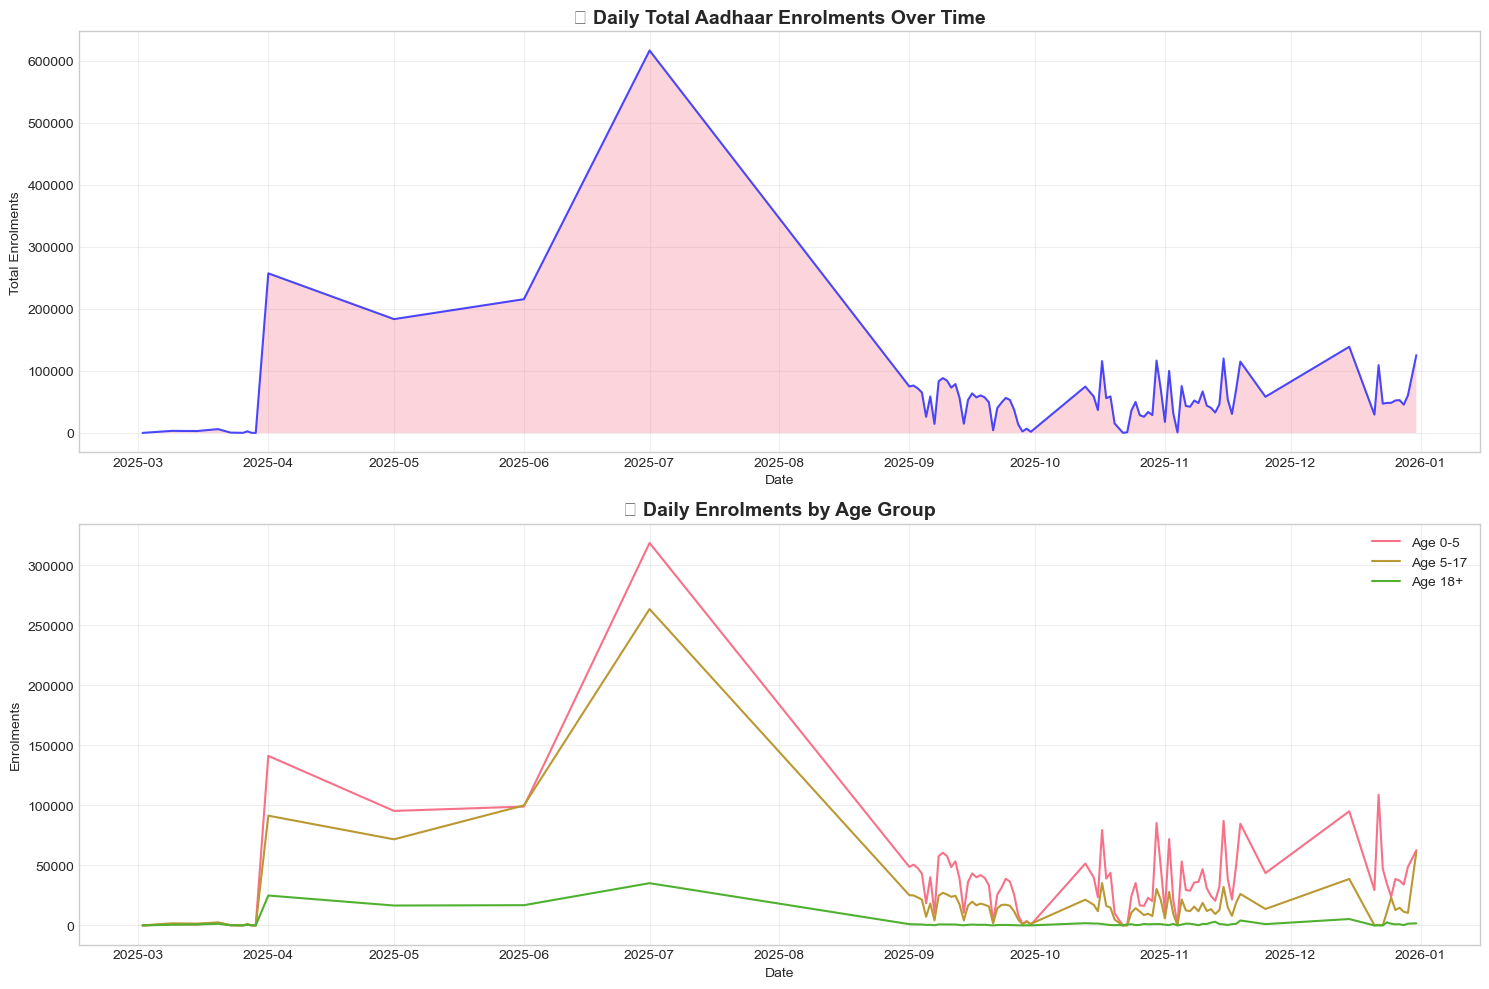

In [46]:
# Daily enrolment trends
daily_enrolment = df_enrolment.groupby('date').agg({
    'age_0_5': 'sum',
    'age_5_17': 'sum',
    'age_18_greater': 'sum',
    'total_enrolment': 'sum'
}).reset_index()

print("\nDaily Enrolment Trends (sample): \n")
display(daily_enrolment.head())

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Total daily enrolments
axes[0].plot(daily_enrolment['date'], daily_enrolment['total_enrolment'], 
             linewidth=1.5, color='blue', alpha=0.7)
axes[0].fill_between(daily_enrolment['date'], daily_enrolment['total_enrolment'], alpha=0.3)
axes[0].set_title('📅 Daily Total Aadhaar Enrolments Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Enrolments')
axes[0].grid(True, alpha=0.3)

# Enrolments by age group
axes[1].plot(daily_enrolment['date'], daily_enrolment['age_0_5'], label='Age 0-5', linewidth=1.5)
axes[1].plot(daily_enrolment['date'], daily_enrolment['age_5_17'], label='Age 5-17', linewidth=1.5)
axes[1].plot(daily_enrolment['date'], daily_enrolment['age_18_greater'], label='Age 18+', linewidth=1.5)
axes[1].set_title('👥 Daily Enrolments by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Enrolments')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

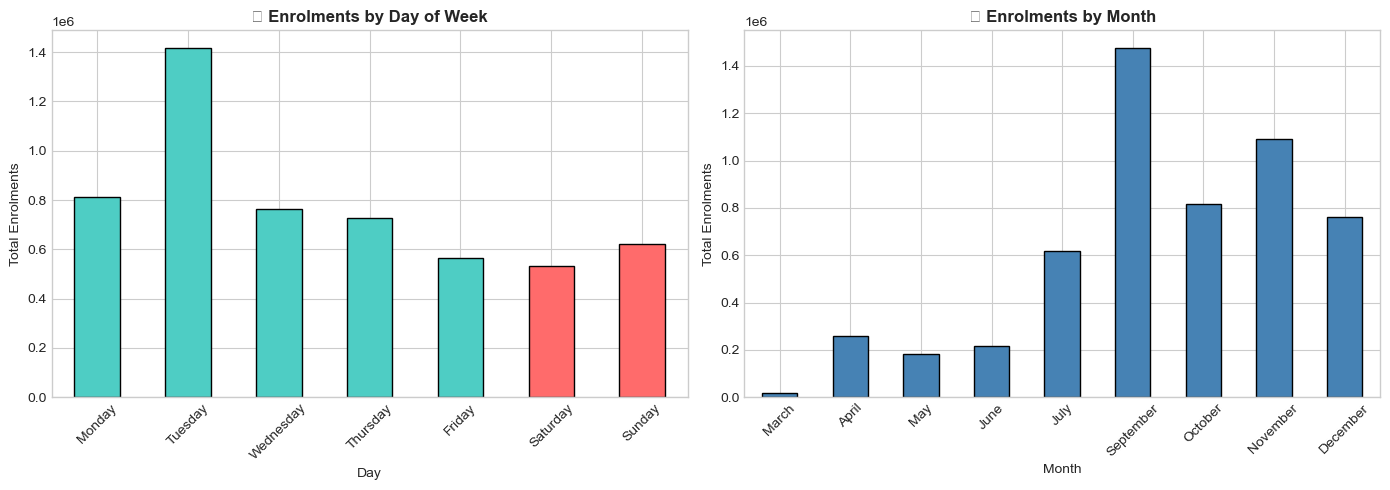

In [40]:
# Day of week analysis - Are there patterns based on weekdays?
dow_enrolment = df_enrolment.groupby('day_of_week')['total_enrolment'].sum()

# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_enrolment = dow_enrolment.reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for day of week
colors = ['#FF6B6B' if day in ['Saturday', 'Sunday'] else '#4ECDC4' for day in day_order]
dow_enrolment.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('📅 Enrolments by Day of Week', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Enrolments')
axes[0].tick_params(axis='x', rotation=45)

# Monthly trends
monthly_enrolment = df_enrolment.groupby('month_name')['total_enrolment'].sum()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_enrolment = monthly_enrolment.reindex([m for m in month_order if m in monthly_enrolment.index])

monthly_enrolment.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('📆 Enrolments by Month', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Enrolments')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Age Group Analysis & Demographics

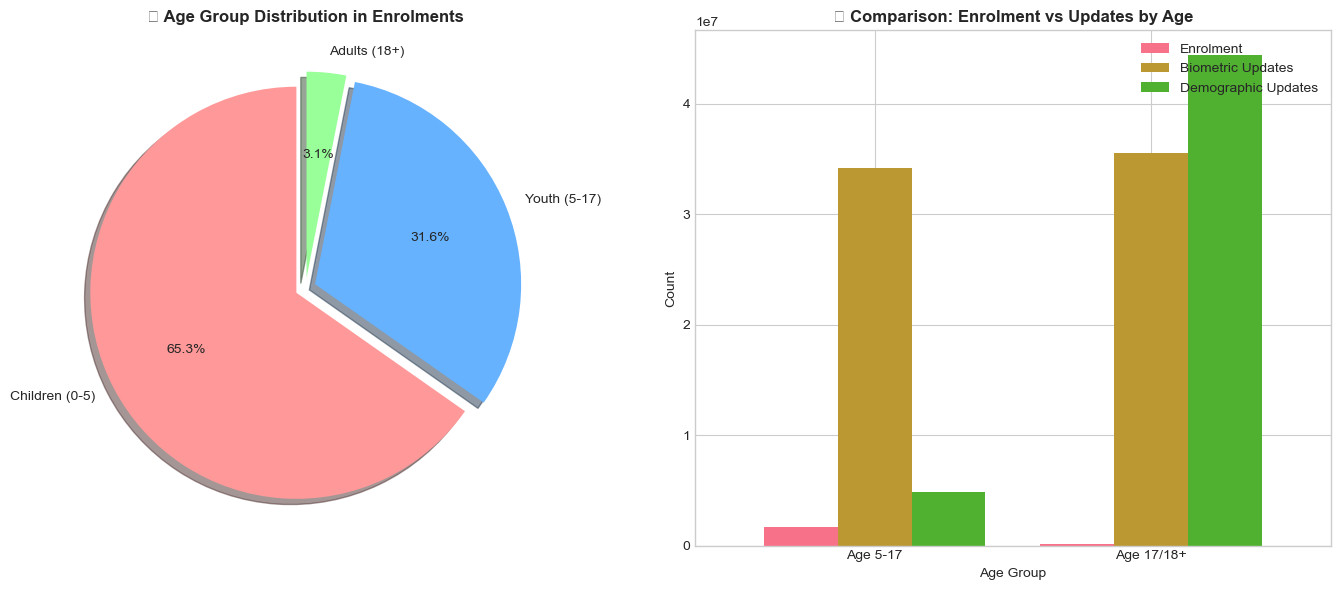


📊 Total Records Summary:
   Total Enrolments: 5,435,702
   Total Biometric Updates: 69,763,095
   Total Demographic Updates: 49,295,187


In [41]:
# Age group composition analysis
age_totals = {
    'Children (0-5)': df_enrolment['age_0_5'].sum(),
    'Youth (5-17)': df_enrolment['age_5_17'].sum(),
    'Adults (18+)': df_enrolment['age_18_greater'].sum()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#FF9999', '#66B2FF', '#99FF99']
explode = (0.05, 0.05, 0.05)
axes[0].pie(age_totals.values(), labels=age_totals.keys(), autopct='%1.1f%%', 
            colors=colors, explode=explode, shadow=True, startangle=90)
axes[0].set_title('👥 Age Group Distribution in Enrolments', fontsize=12, fontweight='bold')

# Comparison of update types by age
update_comparison = pd.DataFrame({
    'Enrolment': [df_enrolment['age_5_17'].sum(), df_enrolment['age_18_greater'].sum()],
    'Biometric Updates': [df_biometric['bio_age_5_17'].sum(), df_biometric['bio_age_17_'].sum()],
    'Demographic Updates': [df_demographic['demo_age_5_17'].sum(), df_demographic['demo_age_17_'].sum()]
}, index=['Age 5-17', 'Age 17/18+'])

update_comparison.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('🔄 Comparison: Enrolment vs Updates by Age', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n📊 Total Records Summary:")
print(f"   Total Enrolments: {sum(age_totals.values()):,}")
print(f"   Total Biometric Updates: {df_biometric['total_bio'].sum():,}")
print(f"   Total Demographic Updates: {df_demographic['total_demo'].sum():,}")

## 6. Anomaly Detection - Identifying Outliers

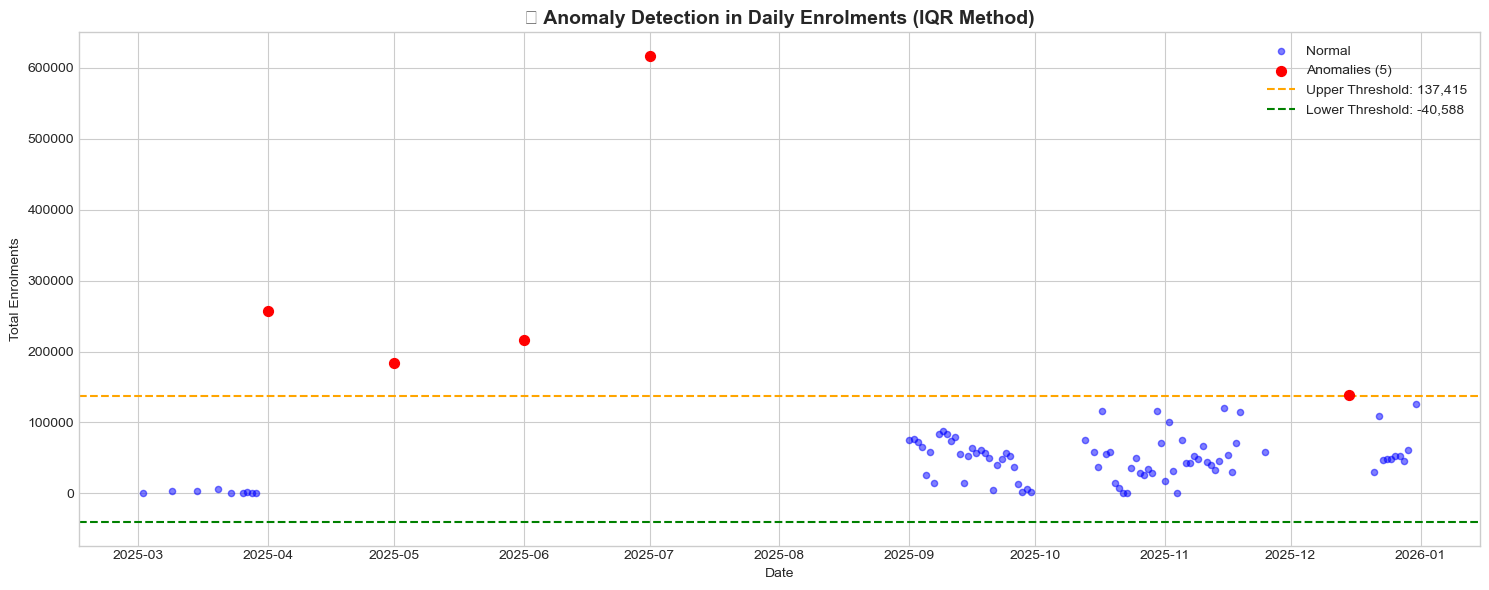


🔍 Anomaly Summary:
   Total anomalous days: 5
   Upper threshold: 137,415
   Lower threshold: -40,588


In [42]:
# Detect anomalies using IQR method on daily enrolments
def detect_anomalies_iqr(df, column):
    """Detect anomalies using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    anomalies = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return anomalies, lower_bound, upper_bound

anomalies, lower, upper = detect_anomalies_iqr(daily_enrolment, 'total_enrolment')

fig, ax = plt.subplots(figsize=(15, 6))

# Plot normal data
normal_data = daily_enrolment[~daily_enrolment.index.isin(anomalies.index)]
ax.scatter(normal_data['date'], normal_data['total_enrolment'], 
           alpha=0.5, label='Normal', color='blue', s=20)

# Highlight anomalies
ax.scatter(anomalies['date'], anomalies['total_enrolment'], 
           color='red', s=50, label=f'Anomalies ({len(anomalies)})', zorder=5)

# Add threshold lines
ax.axhline(y=upper, color='orange', linestyle='--', label=f'Upper Threshold: {upper:,.0f}')
ax.axhline(y=lower, color='green', linestyle='--', label=f'Lower Threshold: {lower:,.0f}')

ax.set_title('🚨 Anomaly Detection in Daily Enrolments (IQR Method)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Enrolments')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n🔍 Anomaly Summary:")
print(f"   Total anomalous days: {len(anomalies)}")
print(f"   Upper threshold: {upper:,.0f}")
print(f"   Lower threshold: {lower:,.0f}")

In [43]:
# District-level anomaly analysis - Find districts with unusual patterns
district_stats = df_enrolment.groupby(['state', 'district']).agg({
    'total_enrolment': ['mean', 'std', 'sum', 'count']
}).reset_index()
district_stats.columns = ['state', 'district', 'mean', 'std', 'total', 'count']

# Coefficient of Variation (CV) - high CV indicates inconsistent enrolment patterns
district_stats['cv'] = district_stats['std'] / district_stats['mean']

# Top districts with high variability (potential anomalies)
high_variability = district_stats.nlargest(10, 'cv')

print("⚠️ Districts with High Enrolment Variability (Potential Anomalies):")
display(high_variability[['state', 'district', 'mean', 'std', 'cv', 'total']])

⚠️ Districts with High Enrolment Variability (Potential Anomalies):


,state,district,mean,std,cv,total
564,Maharashtra,Raigad,3.606092,39.295361,10.896937,3433
530,Maharashtra,Aurangabad,7.803051,83.565470,10.709333,17393
931,Uttar Pradesh,Firozabad,10.837004,106.634580,9.839858,12300
720,Punjab,Amritsar,6.169329,57.521741,9.323824,9655
906,Uttar Pradesh,Ayodhya,2.508148,23.375172,9.319694,1693
915,Uttar Pradesh,Barabanki,6.884058,63.674120,9.249504,2375
831,Tamil Nadu,Thiruvallur,2.713004,23.095925,8.513044,605
968,Uttar Pradesh,Prayagraj,2.795122,23.677665,8.471067,2865
964,Uttar Pradesh,Moradabad,20.776278,169.575805,8.161992,21545
559,Maharashtra,Nashik,5.982348,47.604457,7.957487,22368


## 7. Correlation & Heatmap Analysis

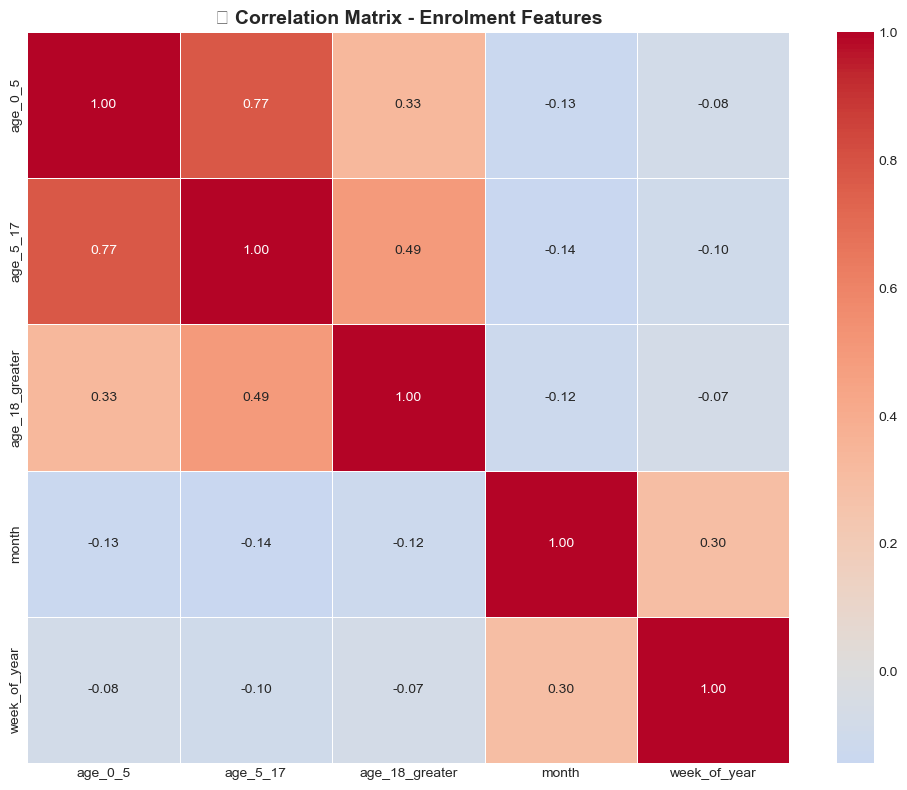

In [44]:
# Correlation analysis for enrolment data
correlation_cols = ['age_0_5', 'age_5_17', 'age_18_greater', 'month', 'week_of_year']
corr_matrix = df_enrolment[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('🔗 Correlation Matrix - Enrolment Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Key Insights & Recommendations

In [47]:
# Generate automated insights
print("=" * 70)
print("📊 KEY INSIGHTS & FINDINGS")
print("=" * 70)

# 1. Top performing states
top_states = state_enrolment.head(5)
print("\nTOP 5 STATES BY ENROLMENT:")
for i, (state, count) in enumerate(top_states.items(), 1):
    print(f"   {i}. {state}: {count:,} enrolments")
    
top_states = state_bio.sort_values(ascending=False).head(5)
print("\nTOP 5 STATES BY BIOMETRIC UPDATES:")
for i, (state, count) in enumerate(top_states.items(), 1):
    print(f"   {i}. {state}: {count:,} biometric updates")

# 2. Age group insights
total_enrol = sum(age_totals.values())
print(f"\nAGE GROUP BREAKDOWN:")
for group, count in age_totals.items():
    pct = (count / total_enrol) * 100
    print(f"   • {group}: {count:,} ({pct:.1f}%)")

# 3. Temporal patterns
peak_day = dow_enrolment.idxmax()
low_day = dow_enrolment.idxmin()
print(f"\nTEMPORAL PATTERNS:")
print(f"   • Peak enrolment day: {peak_day}")
print(f"   • Lowest enrolment day: {low_day}")

# 4. Update ratios
bio_total = df_biometric['total_bio'].sum()
demo_total = df_demographic['total_demo'].sum()
print(f"\n🔄 UPDATE ANALYSIS:")
print(f"   • Total Biometric Updates: {bio_total:,}")
print(f"   • Total Demographic Updates: {demo_total:,}")
print(f"   • Bio:Demo Ratio: {bio_total/demo_total:.2f}:1")

print("\n" + "=" * 70)
print("💡 RECOMMENDATIONS")
print("=" * 70)
print("""
1. RESOURCE ALLOCATION: Focus resources on top-performing states
   for maximum impact and scale operations accordingly.

2. CHILD ENROLMENT CAMPAIGNS: Design targeted campaigns for 0-5 age
   group as they represent new Aadhaar generation.

3. OPERATIONAL PLANNING: Increase staff on peak days, consider
   incentives for low-activity days.

4. BIOMETRIC UPDATE DRIVES: Given high biometric update volume,
   ensure adequate biometric capture infrastructure.

5. ANOMALY INVESTIGATION: Investigate districts with high variability
   for potential data quality or operational issues.
""")

📊 KEY INSIGHTS & FINDINGS

TOP 5 STATES BY ENROLMENT:
   1. Uttar Pradesh: 1,018,629 enrolments
   2. Bihar: 609,585 enrolments
   3. Madhya Pradesh: 493,970 enrolments
   4. West Bengal: 375,297 enrolments
   5. Maharashtra: 369,139 enrolments

TOP 5 STATES BY BIOMETRIC UPDATES:
   1. Uttar Pradesh: 9,577,735 biometric updates
   2. Maharashtra: 9,226,139 biometric updates
   3. Madhya Pradesh: 5,923,771 biometric updates
   4. Bihar: 4,897,587 biometric updates
   5. Tamil Nadu: 4,698,117 biometric updates

AGE GROUP BREAKDOWN:
   • Children (0-5): 3,546,965 (65.3%)
   • Youth (5-17): 1,720,384 (31.6%)
   • Adults (18+): 168,353 (3.1%)

TEMPORAL PATTERNS:
   • Peak enrolment day: Tuesday
   • Lowest enrolment day: Saturday

🔄 UPDATE ANALYSIS:
   • Total Biometric Updates: 69,763,095
   • Total Demographic Updates: 49,295,187
   • Bio:Demo Ratio: 1.42:1

💡 RECOMMENDATIONS

1. RESOURCE ALLOCATION: Focus resources on top-performing states
   for maximum impact and scale operations accor